# Lecture 3b: Statistical Distributions, Binning & Image Plots

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # Load seaborn's default theme and color palette

---
## 1. Normal Distribution

**Formula:** `sigma * np.random.randn(...) + mu`
- Generates random samples from normal distribution
- `mu` = mean, `sigma` = standard deviation
- `np.random.randn(...)` on its own gives the *standard* normal distribution (`mu = 0`, `sigma = 1`)

sample mean = 4.90
sample std  = 1.98
ERROR! Session/line number was not unique in database. History logging moved to new session 10


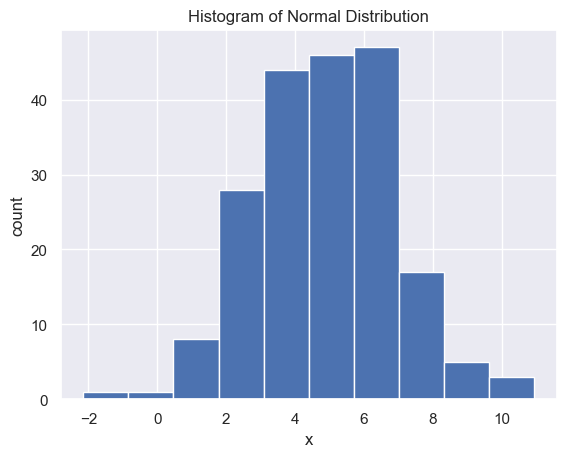

In [2]:
mu = 5       # mean
sigma = 2    # standard deviation

# Generate 200 random samples from a normal distribution
x = sigma * np.random.randn(200) + mu

# The sample mean and standard deviation should be close to mu and sigma
print(f"sample mean = {x.mean():.2f}")
print(f"sample std  = {x.std():.2f}")

# Visualize with histogram
plt.hist(x)
plt.title('Histogram of Normal Distribution')
plt.xlabel('x')
plt.ylabel('count')
plt.show()

### Kernel Density Estimate (KDE) Plot

A method for visualizing distributions, analogous to histograms.
- Represents data using a **continuous probability density curve**
- Smoother than histograms

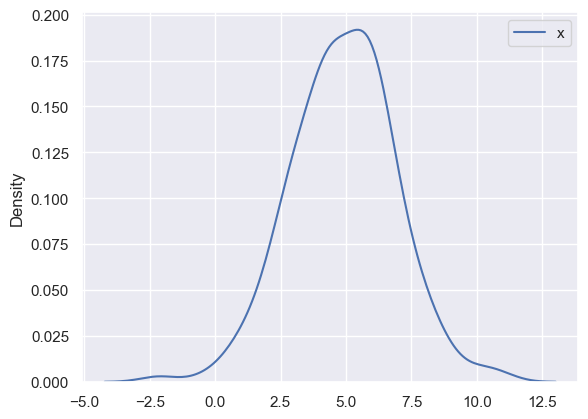

In [3]:
ax = sns.kdeplot(x, label='x')
ax.legend(loc="upper right")
plt.show()

---
## 2. Multivariate Normal Distribution

**Definition:** Generalization of 1D normal distribution to higher dimensions
- Also called: multinormal or Gaussian distribution
- Specified by **mean vector** and **covariance matrix**
- Covariance matrix describes correlations between variables

In [4]:
# Define parameters
mean = [0, 0]  # Mean values for two variables. One mean per variable: x is centred at 0, y is centred at 0.
covariance = [[5, 2], [2, 2]]  # Covariance matrix. 
# More notes covariance matrix:
# Covariance matrix, read as:
#   [[var(x),    cov(x,y)],
#    [cov(x,y),  var(y)  ]]
# So x has variance 5 (std ≈ 2.24), y has variance 2 (std ≈ 1.41),
# and their covariance is 2, i.e. they tend to move together.
# Correlation = 2 / sqrt(5 * 2) ≈ 0.63.

# Generate 2000 samples
data = np.random.multivariate_normal(mean, covariance, size=2000)
data = pd.DataFrame(data, columns=['x', 'y'])

print(data.x)
print(data.y) 
print(data)

0       3.023173
1      -0.330165
2       1.717473
3       0.438699
4       1.298548
          ...   
1995    0.814909
1996    1.476179
1997   -2.352094
1998    0.482134
1999    1.081076
Name: x, Length: 2000, dtype: float64
0       0.296165
1       1.607933
2       1.659156
3       2.484650
4      -0.924181
          ...   
1995    0.346615
1996    1.682693
1997   -0.900140
1998   -0.803949
1999    2.528141
Name: y, Length: 2000, dtype: float64
             x         y
0     3.023173  0.296165
1    -0.330165  1.607933
2     1.717473  1.659156
3     0.438699  2.484650
4     1.298548 -0.924181
...        ...       ...
1995  0.814909  0.346615
1996  1.476179  1.682693
1997 -2.352094 -0.900140
1998  0.482134 -0.803949
1999  1.081076  2.528141

[2000 rows x 2 columns]


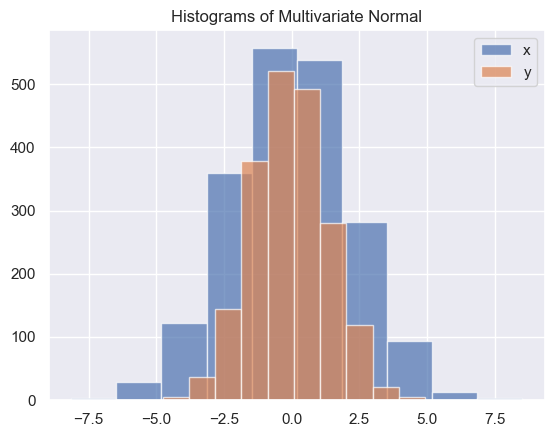

In [5]:
# Histogram for each variable
for col in 'xy':
    plt.hist(data[col], alpha=0.7, label=col)
plt.legend()
plt.title('Histograms of Multivariate Normal')
plt.show()

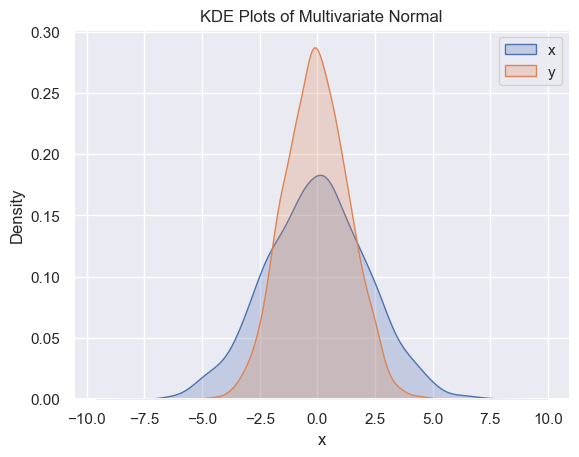

In [6]:
# KDE plot for each variable
for col in 'xy':
    sns.kdeplot(data[col], fill=True, label=col)
plt.legend()
plt.title('KDE Plots of Multivariate Normal')
plt.show()

### Seeing the correlation
The histograms and KDE curves above show each variable **on its own**. They cannot show how `x` and `y` are related. For that, plot one variable against the other.

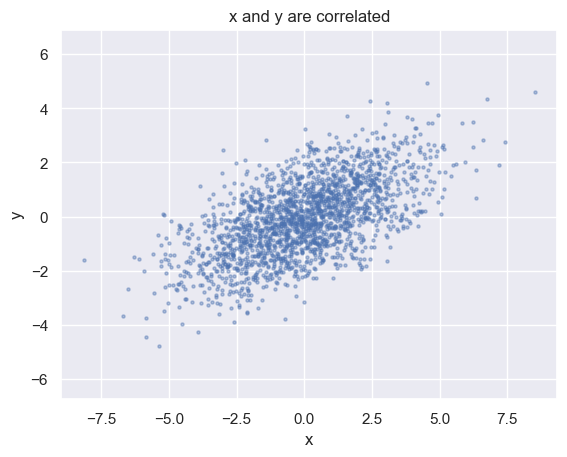

[[4.85739743 1.88341956]
 [1.88341956 1.93324396]]


In [7]:
plt.scatter(data.x, data.y, s=5, alpha=0.4)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title('x and y are correlated')
plt.show()

# Covariance measured from the samples: close to the matrix we asked for
print(np.cov(data.x, data.y))

---
## 3. Binary Search with `np.searchsorted()`

**Purpose:** Find indices where values should be inserted to maintain sorted order
- Efficient for sorted arrays
- Returns insertion indices

### Basic Usage

In [8]:
arr = np.array([1, 2, 4, 8, 9])
value = 5
index = np.searchsorted(arr, value)

print(f"Insert {value} at index {index}")  # Output: 3
print(f"Result: {np.insert(arr, index, value)}")

Insert 5 at index 3
Result: [1 2 4 5 8 9]


### Multiple Values

In [9]:
arr = np.array([1, 2, 4, 8, 9])
values = np.array([3, 5, 6, 7])
indices = np.searchsorted(arr, values)

print(f"Values: {values}")
print(f"Insertion indices: {indices}")
print(f"Result: {np.insert(arr, indices, values)}")

Values: [3 5 6 7]
Insertion indices: [2 3 3 3]
Result: [1 2 3 4 5 6 7 8 9]


### Left vs Right Side (Handling Duplicates)

- `side='left'`: Returns index of **first occurrence**
- `side='right'`: Returns index **after last occurrence**

In [10]:
arr = np.array([1, 3, 5, 5, 5, 7, 9])
value = 5

index_left = np.searchsorted(arr, value, side='left')
index_right = np.searchsorted(arr, value, side='right')

print(f"Array: {arr}")
print(f"Value: {value}")
print(f"Left index (first occurrence): {index_left}")  # Output: 2
print(f"Right index (after last): {index_right}")      # Output: 5

Array: [1 3 5 5 5 7 9]
Value: 5
Left index (first occurrence): 2
Right index (after last): 5


---
## 4. Grid Mapping Tutorial

In [26]:
import numpy as np
#lets say we have an array with values between 0 and 2
arr = np.array([0, 1, 1.2, 0.3, 1.4, 0.4, 0.7, 0.8, 0.2, 0.2, 2.0])
print(arr)

[0.  1.  1.2 0.3 1.4 0.4 0.7 0.8 0.2 0.2 2. ]


In [27]:
#lets set a 1D grid such that there are 5 grid points
Ng=5
grid_arr = np.linspace(0 , 2, Ng)
print(grid_arr) #output: [0.  0.5 1.  1.5 2. ]

[0.  0.5 1.  1.5 2. ]


In [34]:
# #next we want to approximate such that overlapping or close by values of arr array are all assigned to the grid_arr values. 
# #numpy.searchsorted function can be helpful for this purpose
idx = np.searchsorted(grid_arr,arr) #idx is an array of indices showing where arr values should be inserted in grid_arr to maintain the order
print(idx) #output: [0 2 3 1 3 1 2 2 1 1 4]

[0 2 3 1 3 1 2 2 1 1 4]


In [38]:
# #to see what searchsorted did, we can insert the arr values into grid_arr at the indices it found
# #we sort arr first so that the final array comes out fully sorted (arr and idx are not changed)
arr_sorted = np.sort(arr)
final = np.insert(grid_arr, np.searchsorted(grid_arr, arr_sorted), arr_sorted)
print(final)
# #output: [0.  0.  0.2 0.2 0.3 0.4 0.5 0.7 0.8 1.  1.  1.2 1.4 1.5 2.  2. ]
# #the values sitting just before each grid value are the ones assigned to it:
# #  0                    -> grid value 0
# #  0.2, 0.2, 0.3, 0.4   -> grid value 0.5
# #  0.7, 0.8, 1.0        -> grid value 1
# #  1.2, 1.4             -> grid value 1.5
# #  2.0                  -> grid value 2

[0.  0.  0.2 0.2 0.3 0.4 0.5 0.7 0.8 1.  1.  1.2 1.4 1.5 2.  2. ]


In [29]:
# #to count the number of arr values that will match to the specific grid_arr, we first create an empty array
Npt = np.zeros((Ng))
#to find, for example, average values, we create an empty array first
sum = np.zeros((Ng))

In [30]:
# #loop over each one of arr elements and fill up the empty arrays using idx 
# #To see how this algorithm works, write it down on a piece of paper and map the indices and arr values to grid_arr yourself
for i in range(np.size(arr)):
    Npt[idx[i]]+=1
    sum[idx[i]]+=arr[i]
print(Npt)

[1. 4. 3. 2. 1.]


In [7]:
avg = np.divide(sum, Npt)
print(avg)

[0.         0.275      0.83333333 1.3        2.        ]


---
## 5. The Same Idea in 2D (Lab 3B)

The notes above map **one** array of values onto a 1D grid, then count and average the values at each grid position. In Lab 3B you will do exactly this in **two directions at once**.

### What gets gridded
Think back to your colour plots from Lab 3A (Parts 2 and 3). Every point has
- a **position**: peak separation Δ and shell parameter S
- a **colour**: the inclination I

Where many points overlap, the colours are hard to read. Gridding fixes that.

### The grid
Draw grid lines in the Δ direction **and** in the S direction. Together they cut the plot into rectangular **cells**, like graph paper. Every point falls in one cell, and each cell collects the points inside it.

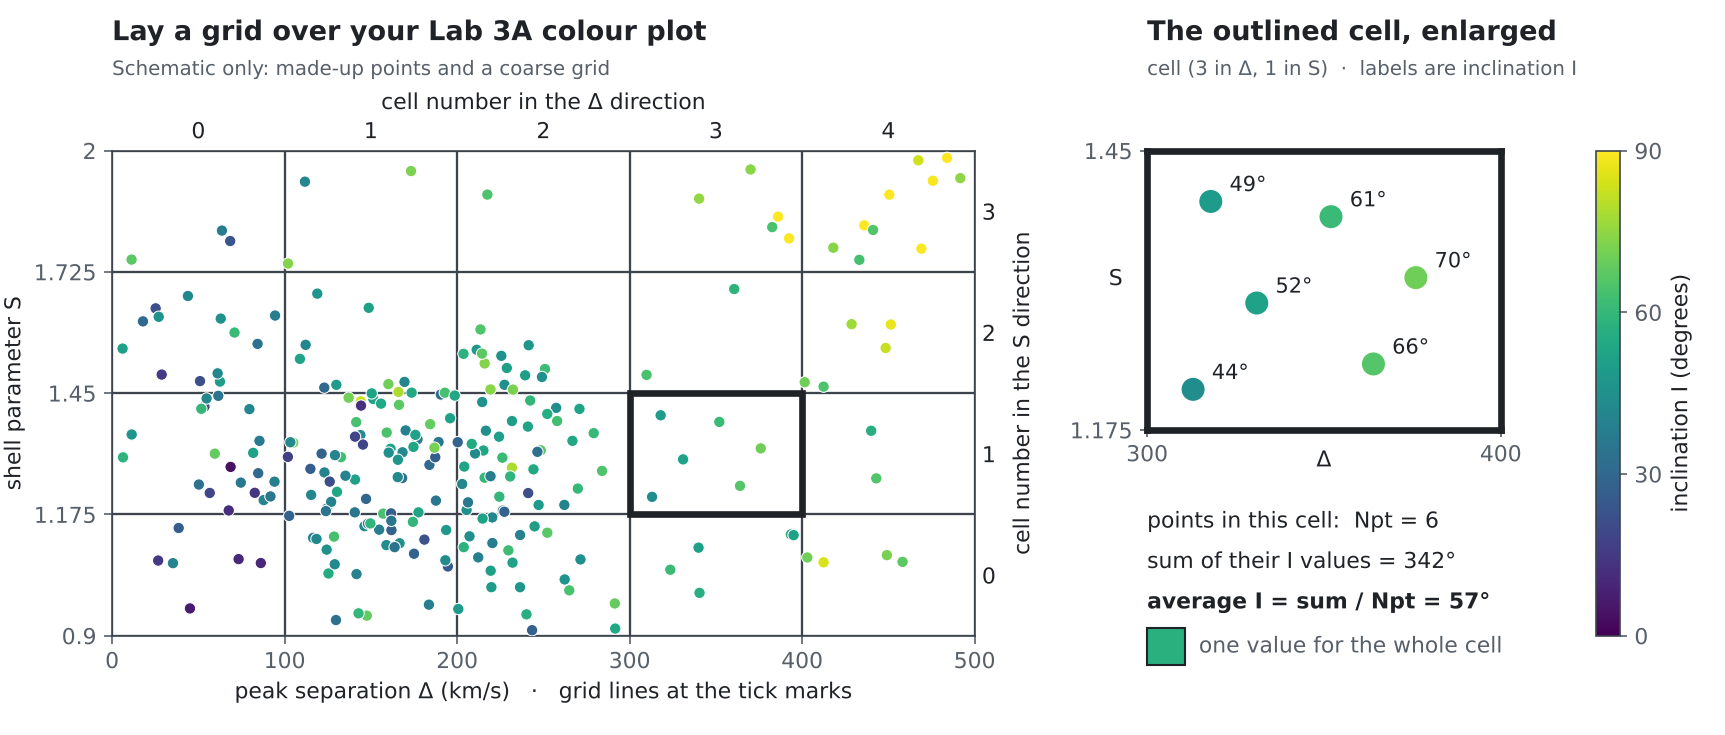

Schematic only: **the points are made up** and the grid is **coarse**. **In the lab you use your own data and a finer grid.**


### Think about these before you start:
- A 2D array is indexed as `a[row, column]`. Which direction, Δ or S, should be the row?
- Some of the data lie outside the grid. Which cell do those points belong to?
- What is the average of a cell that has no points in it?